# Inferencia con Qwen2.5-VL — Entrada: imagen + texto

## Importar librerías

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import json
import os
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc
)

from pyevall.evaluation import PyEvALLEvaluation
from pyevall.metrics.metricfactory import MetricFactory

In [2]:
# Instalar dependencias necesarias
import subprocess
import sys

try:
    import qwen_vl_utils
    print("qwen-vl-utils ya está instalado")
except ImportError:
    print("Instalando qwen-vl-utils...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "qwen-vl-utils", "-q"])
    print("qwen-vl-utils instalado correctamente")

qwen-vl-utils ya está instalado


## Configuración y parámetros

In [3]:
os.environ["HF_TOKEN"] = ""

MODEL_NAME = "Qwen/Qwen2.5-VL-7B-Instruct"
MAIN_PATH  = ".."
GROUP_ID   = "BeingChillingWeWillWin"
MODEL_ID   = "qwen25vl_7b"

TEXT_COLUMN  = "combined_text"
LABEL_COLUMN = "label"

DATA_TRAIN_PATH = os.path.join(MAIN_PATH, "preprocessed_data", "train_split.json")
DATA_VAL_PATH   = os.path.join(MAIN_PATH, "preprocessed_data", "dev_split.json")
DATA_TEST_PATH  = os.path.join(MAIN_PATH, "preprocessed_data", "test_split.json")

DATA_BASE_DIR   = os.path.join(MAIN_PATH, "materials", "dataset_task2_exist2026")
PREDICTIONS_DIR = os.path.join(MAIN_PATH, "predictions")
os.makedirs(PREDICTIONS_DIR, exist_ok=True)

MAX_NEW_TOKENS = 512
TEMPERATURE    = 0.3
TOP_P          = 0.9

# Parámetros para Qwen2.5-VL
MIN_PIXELS = 224 * 224
MAX_PIXELS = 768 * 768

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

label_map         = {"NO": 0, "YES": 1}
label_map_inverse = {0: "NO", 1: "YES"}

## Carga y preprocesamiento de datos

In [4]:
def load_json_dataset(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data.values())

def build_combined_text(row):
    img_desc = str(row.get('image_description', '') or '')
    txt      = str(row.get('text', '') or '')
    return f"descripcion imagen: {img_desc}. Texto: {txt}"

train_df = load_json_dataset(DATA_TRAIN_PATH)
val_df   = load_json_dataset(DATA_VAL_PATH)
test_df  = load_json_dataset(DATA_TEST_PATH)

for df in [train_df, val_df, test_df]:
    df[TEXT_COLUMN] = df.apply(build_combined_text, axis=1)

train_df["label_int"] = train_df[LABEL_COLUMN].map(label_map)
val_df["label_int"]   = val_df[LABEL_COLUMN].map(label_map)
test_df["label_int"]  = -1

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
print(f"\nEjemplo de entrada:\n  {train_df[TEXT_COLUMN].iloc[0][:200]}")
print(f"\nDistribución de etiquetas en TRAIN:")
print(train_df[LABEL_COLUMN].value_counts())
print(f"\nDistribución de etiquetas en VAL:")
print(val_df[LABEL_COLUMN].value_counts())

Train size: 2146 | Val size: 537 | Test size: 687

Ejemplo de entrada:
  descripcion imagen: a close up of a snake with its mouth open and its tongue out. Texto: Demostración de que las cosas mas peligrosas del mundo tienen el mismo aspecto. mémenoides 

Distribución de etiquetas en TRAIN:
label
YES    1282
NO      864
Name: count, dtype: int64

Distribución de etiquetas en VAL:
label
YES    321
NO     216
Name: count, dtype: int64


## Carga del modelo Qwen2.5-VL

In [5]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto",
    ignore_mismatched_sizes=True
).eval()

processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS
)

# Configurar pad_token para evitar warnings repetitivos
if hasattr(processor, 'tokenizer') and processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token
    processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id

print(f"Modelo Qwen2.5-VL cargado en {DEVICE}")
print(f"Procesador configurado con min_pixels={MIN_PIXELS}, max_pixels={MAX_PIXELS}")

You are using a model of type `qwen2_5_vl` to instantiate a model of type `qwen2_vl`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/537 [00:00<?, ?it/s]

Qwen2VLForConditionalGeneration LOAD REPORT from: Qwen/Qwen2.5-VL-7B-Instruct
Key                                               | Status     |                                                                                               
--------------------------------------------------+------------+-----------------------------------------------------------------------------------------------
model.visual.blocks.{0...31}.mlp.gate_proj.weight | UNEXPECTED |                                                                                               
model.visual.blocks.{0...31}.mlp.gate_proj.bias   | UNEXPECTED |                                                                                               
model.visual.blocks.{0...31}.mlp.down_proj.weight | UNEXPECTED |                                                                                               
model.visual.blocks.{0...31}.mlp.up_proj.bias     | UNEXPECTED |                                                          

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Modelo Qwen2.5-VL cargado en cuda
Procesador configurado con min_pixels=50176, max_pixels=589824


## Funciones de inferencia

In [6]:
def build_classification_prompt(combined_text):
    system_instruction = (
        "You are an expert content moderator specialized in identifying sexist content in memes. "
        "Your task is to analyze both the visual content and the text to determine if the meme "
        "contains sexist elements (stereotypes, discrimination, objectification, or derogatory content "
        "towards any gender).\n\n"
    )
    user_message = (
        f"Analyze this meme carefully. {combined_text}\n\n"
        "Does this meme contain sexist content?\n\n"
        "Answer ONLY with 'YES' if it contains sexist content, or 'NO' if it doesn't.\n"
        "Format: CLASSIFICATION: [YES/NO]"
    )
    return system_instruction + user_message


def parse_model_response(response_text):
    response_upper = response_text.upper()
    
    if "CLASSIFICATION: YES" in response_upper or "CLASSIFICATION:YES" in response_upper:
        classification = "YES"
    elif "CLASSIFICATION: NO" in response_upper or "CLASSIFICATION:NO" in response_upper:
        classification = "NO"
    elif response_upper.strip().startswith("YES"):
        classification = "YES"
    elif response_upper.strip().startswith("NO"):
        classification = "NO"
    else:
        classification = "NO"
        print(f"[WARN] No se pudo parsear: {response_text[:100]}")
    
    confidence = 0.9 if ("CLASSIFICATION:" in response_text) else 0.6
    return classification, confidence

from PIL import Image
@torch.no_grad()
def classify_image(image_path, combined_text, model, processor):
    """
    Clasifica una imagen usando Qwen2.5-VL.
    """
    try:
        prompt = build_classification_prompt(combined_text)
        
        image = Image.open(image_path).convert("RGB")
        
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt}
                ]
            }
        ]
        
        text = processor.apply_chat_template(
            messages, 
            tokenize=False, 
            add_generation_prompt=True
        )
        
        inputs = processor(
            text=[text],
            images=[image],
            padding=True,
            return_tensors="pt"
        )
        
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            do_sample=TEMPERATURE > 0,
            pad_token_id=processor.tokenizer.pad_token_id if hasattr(processor, 'tokenizer') else None
        )
        
        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = processor.decode(generated_ids, skip_special_tokens=True)
        
        classification, confidence = parse_model_response(response)
        return {
            'classification': classification, 
            'confidence': confidence, 
            'raw_response': response
        }
    
    except Exception as e:
        print(f"[ERROR] {image_path.name}: {str(e)}")
        return {
            'classification': 'NO', 
            'confidence': 0.0, 
            'raw_response': ''
        }


def process_dataset(df, base_dir, model, processor, split_name="dev"):
    """
    Procesa un dataset completo y genera predicciones.
    """
    results = []
    base_path = Path(base_dir)
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Inferencia {split_name}"):
        img_path = base_path / row['path_memes']
        prediction = classify_image(img_path, row[TEXT_COLUMN], model, processor)
        
        result = {
            'id_EXIST': str(row['id_EXIST']),
            'classification': prediction['classification'],
            'confidence': prediction['confidence'],
        }
        
        if 'label_int' in row.index and row['label_int'] >= 0:
            result['true_label'] = label_map_inverse[row['label_int']]
        
        results.append(result)
    
    return results


def save_probs_json(ids, probs, split_name, labels=None):
    """
    Guarda las probabilidades en formato JSON.
    """
    records = []
    for i, (id_exist, prob) in enumerate(zip(ids, probs)):
        rec = {'id': str(id_exist), 'prob_YES': round(float(prob), 6)}
        if labels is not None:
            rec['label'] = label_map_inverse[int(labels[i])]
        records.append(rec)
    path = os.path.join(PREDICTIONS_DIR, f'{GROUP_ID}_{MODEL_ID}_probs_{split_name}.json')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print(f"Probabilidades guardadas en: {path}")

## Inferencia en DEV y evaluación

Inferencia dev:   0%|          | 0/537 [00:00<?, ?it/s]

[ERROR] 111904.jpeg: Image features and image tokens do not match, tokens: 196, features: 196
[ERROR] 210576.jpeg: Image features and image tokens do not match, tokens: 400, features: 400


[ERROR] 111632.jpeg: Image features and image tokens do not match, tokens: 729, features: 729
[ERROR] 210421.png: Image features and image tokens do not match, tokens: 345, features: 345


[ERROR] 210857.jpeg: Image features and image tokens do not match, tokens: 494, features: 494
[ERROR] 211285.jpeg: Image features and image tokens do not match, tokens: 294, features: 294


[ERROR] 210059.jpeg: Image features and image tokens do not match, tokens: 713, features: 713
[ERROR] 211706.jpeg: Image features and image tokens do not match, tokens: 437, features: 437


...

[ERROR] 111456.jpeg: Image features and image tokens do not match, tokens: 728, features: 728
[ERROR] 110002.jpeg: Image features and image tokens do not match, tokens: 273, features: 273


[ERROR] 211096.jpeg: Image features and image tokens do not match, tokens: 567, features: 567
[ERROR] 111008.jpeg: Image features and image tokens do not match, tokens: 272, features: 272


[ERROR] 210046.jpeg: Image features and image tokens do not match, tokens: 713, features: 713


[ERROR] 211278.jpeg: Image features and image tokens do not match, tokens: 725, features: 725
[ERROR] 210694.jpeg: Image features and image tokens do not match, tokens: 702, features: 702


[ERROR] 211455.jpeg: Image features and image tokens do not match, tokens: 324, features: 324
Probabilidades guardadas en: ../predictions/BeingChillingWeWillWin_qwen25vl_7b_probs_dev.json

Métricas en DEV:
  Accuracy : 0.4022
  Precision: 0.0000
  Recall   : 0.0000
  F1-Score : 0.0000

AUC (DEV): 0.5000


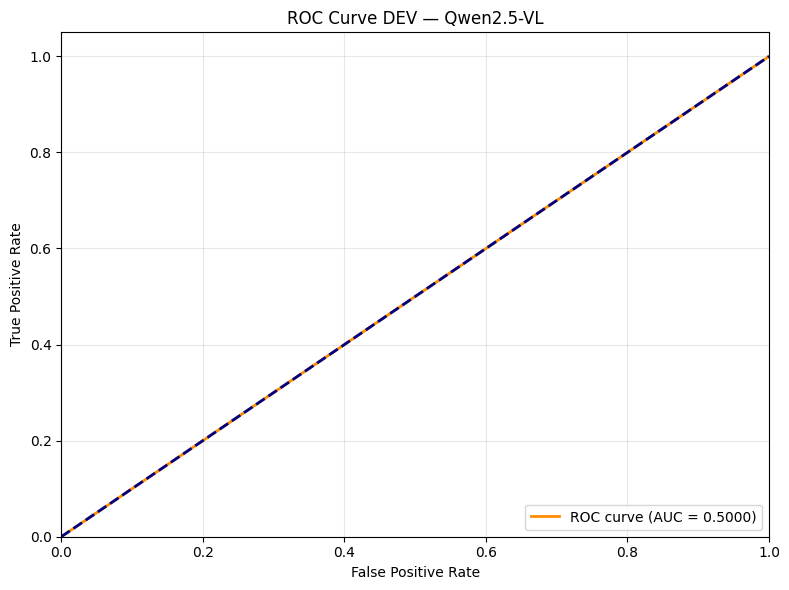

In [7]:
val_results = process_dataset(val_df, DATA_BASE_DIR, model, processor, split_name="dev")

y_pred_labels = [label_map[r['classification']] for r in val_results]
y_true_labels = [label_map[r['true_label']] for r in val_results]
y_probs_dev   = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in val_results]

accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_labels, y_pred_labels, average='binary', zero_division=0
)

save_probs_json(val_df['id_EXIST'].values, y_probs_dev, 'dev', labels=val_df['label_int'].values)

print(f"\nMétricas en DEV:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

fpr, tpr, _ = roc_curve(y_true_labels, y_probs_dev)
roc_auc = auc(fpr, tpr)
print(f"\nAUC (DEV): {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve DEV — Qwen2.5-VL')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluación en DEV con PyEvALL

In [8]:
dev_preds_for_pyevall = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in val_results
]
dev_preds_df   = pd.DataFrame(dev_preds_for_pyevall)
dev_preds_path = os.path.join(PREDICTIONS_DIR, 'dev_predictions_temp.json')
with open(dev_preds_path, 'w', encoding='utf-8') as f:
    f.write(dev_preds_df.to_json(orient='records'))

dev_gold = [
    {'test_case': 'EXIST2025', 'id': str(id_exist), 'value': label}
    for id_exist, label in zip(val_df['id_EXIST'].values, val_df[LABEL_COLUMN].values)
]
dev_gold_df   = pd.DataFrame(dev_gold)
dev_gold_path = os.path.join(PREDICTIONS_DIR, 'dev_gold_temp.json')
with open(dev_gold_path, 'w', encoding='utf-8') as f:
    f.write(dev_gold_df.to_json(orient='records'))

test_eval = PyEvALLEvaluation()
metrics   = [MetricFactory.Accuracy.value, MetricFactory.FMeasure.value]
report    = test_eval.evaluate(dev_preds_path, dev_gold_path, metrics)
print("\n=== Evaluación en DEV con PyEvALL ===")
report.print_report()

2026-03-05 22:05:33,298 - pyevall.evaluation - INFO -             evaluate() - Evaluating the following metrics ['Accuracy', 'FMeasure']


2026-03-05 22:05:33,330 - pyevall.metrics.metrics - INFO -             evaluate() - Executing accuracy evaluation method


2026-03-05 22:05:33,390 - pyevall.metrics.metrics - INFO -             evaluate() - Executing fmeasure evaluation method



=== Evaluación en DEV con PyEvALL ===
{
  "metrics": {
    "Accuracy": {
      "name": "Accuracy",
      "acronym": "Acc",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "average": 0.4022346368715084
        }],
        "average_per_test_case": 0.4022346368715084
      }
    },
    "FMeasure": {
      "name": "F-Measure",
      "acronym": "F1",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "classes": {
            "YES": 0,
            "NO": 0.5737051792828686
          },
          "average": 0.2868525896414343
        }],
        "average_per_test_case": 0.2868525896414343
      }
    }
  },
  "files": {
    "dev_predictions_temp.json": {
      "name": "dev_predictions_temp.json",
      "status": "OK",
      "gold": false,
      "description": "Use parameter: report=\"embedded\"!",
      "er

## Inferencia en TEST y generación de predicciones finales

In [9]:
test_results = process_dataset(test_df, DATA_BASE_DIR, model, processor, split_name="test")

y_probs_test = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in test_results]
test_preds   = [r['classification'] for r in test_results]

save_probs_json(test_df['id_EXIST'].values, y_probs_test, 'test')

print(f"\nPredicciones en TEST:")
print(f"  Total: {len(test_preds)}")
print(f"  YES  : {sum(1 for p in test_preds if p == 'YES')} ({100*sum(1 for p in test_preds if p == 'YES')/len(test_preds):.2f}%)")
print(f"  NO   : {sum(1 for p in test_preds if p == 'NO')} ({100*sum(1 for p in test_preds if p == 'NO')/len(test_preds):.2f}%)")

Inferencia test:   0%|          | 0/687 [00:00<?, ?it/s]

[ERROR] 110887.jpeg: Image features and image tokens do not match, tokens: 289, features: 289


[ERROR] 110444.jpeg: Image features and image tokens do not match, tokens: 729, features: 729
[ERROR] 110460.jpeg: Image features and image tokens do not match, tokens: 294, features: 294


[ERROR] 110012.jpeg: Image features and image tokens do not match, tokens: 340, features: 340
[ERROR] 111106.jpeg: Image features and image tokens do not match, tokens: 529, features: 529


[ERROR] 111207.jpeg: Image features and image tokens do not match, tokens: 304, features: 304


...

[ERROR] 210993.jpeg: Image features and image tokens do not match, tokens: 720, features: 720
[ERROR] 210922.jpeg: Image features and image tokens do not match, tokens: 342, features: 342


[ERROR] 211291.jpeg: Image features and image tokens do not match, tokens: 504, features: 504
[ERROR] 211737.jpeg: Image features and image tokens do not match, tokens: 714, features: 714


[ERROR] 210102.jpeg: Image features and image tokens do not match, tokens: 484, features: 484
[ERROR] 210744.jpeg: Image features and image tokens do not match, tokens: 294, features: 294


[ERROR] 211973.jpeg: Image features and image tokens do not match, tokens: 483, features: 483
[ERROR] 211550.png: Image features and image tokens do not match, tokens: 484, features: 484


[ERROR] 210131.jpeg: Image features and image tokens do not match, tokens: 520, features: 520
[ERROR] 210680.jpeg: Image features and image tokens do not match, tokens: 323, features: 323
Probabilidades guardadas en: ../predictions/BeingChillingWeWillWin_qwen25vl_7b_probs_test.json

Predicciones en TEST:
  Total: 687
  YES  : 0 (0.00%)
  NO   : 687 (100.00%)


## Guardar predicciones en formato PyEvALL para TEST

In [10]:
test_preds_for_submission = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in test_results
]
test_preds_df = pd.DataFrame(test_preds_for_submission)

output_filename = f"{GROUP_ID}_{MODEL_ID}.json"
output_path     = os.path.join(PREDICTIONS_DIR, output_filename)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write(test_preds_df.to_json(orient='records'))

print(f"\nPredicciones guardadas en: {output_path}")


Predicciones guardadas en: ../predictions/BeingChillingWeWillWin_qwen25vl_7b.json
